# Diabetes Classification Experiment (scikit-learn)

This notebook performs exploratory data analysis, preprocessing, model training, and evaluation for a binary diabetes classification task.

**Models compared**
- Logistic Regression
- Support Vector Machine (RBF kernel)
- Decision Tree

**Evaluation**
- Train / Validation / Test split: 60% / 20% / 20% (stratified)
- Metrics: Accuracy, Precision, Recall, F1, Confusion Matrix
- Model selection: best hyperparameters chosen on the **validation** set (by F1)

> Note: Preprocessing steps (imputation and scaling) are fit on the training set only to avoid data leakage.

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

df = pd.read_csv("diabetes (1).csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Basic dataset checks
print("Shape:", df.shape)
display(df.dtypes)
display(df.describe())

Shape: (768, 9)


,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Data quality checks

The brief requires checking:
- Correlations
- Feature histograms
- Mean & standard deviation
- Missing values (NaN) and potentially invalid values (often encoded as 0 in medical features)
- Class balance

In [3]:
# Missing values (explicit NaN)
display(df.isna().sum())

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
# Count zeros per column (useful because some medical features cannot realistically be zero)
zero_counts = (df == 0).sum().sort_values(ascending=False)
display(zero_counts)

,0
Outcome,500
Insulin,374
SkinThickness,227
Pregnancies,111
BloodPressure,35
BMI,11
Glucose,5
DiabetesPedigreeFunction,0
Age,0


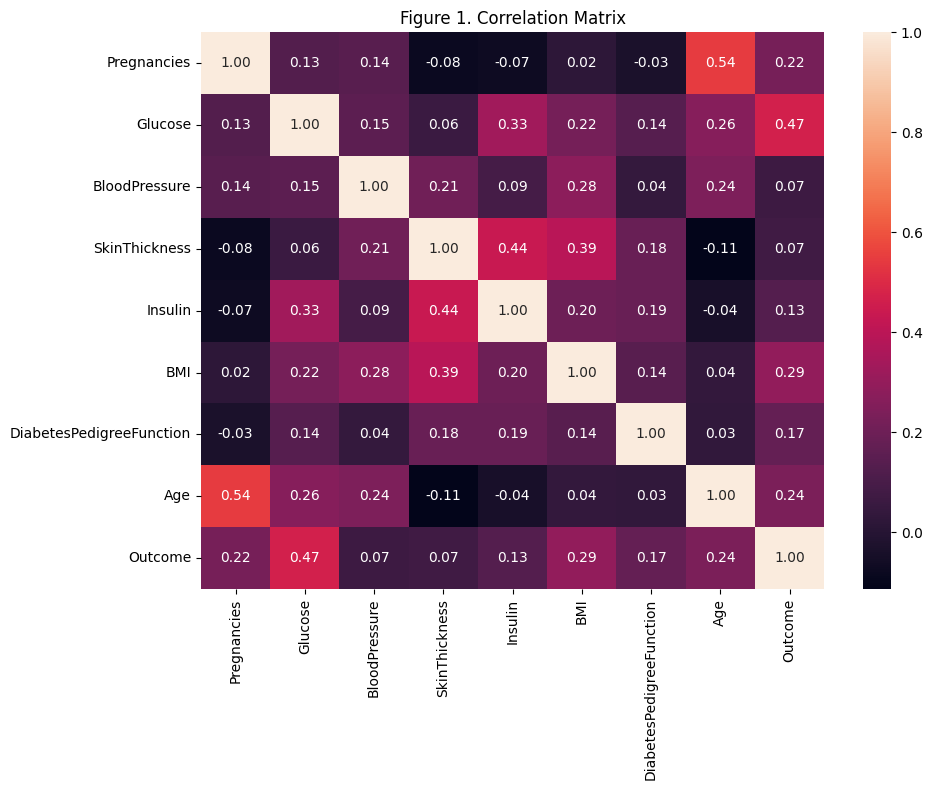

In [5]:
# Correlation matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Figure 1. Correlation Matrix")
plt.tight_layout()
plt.show()

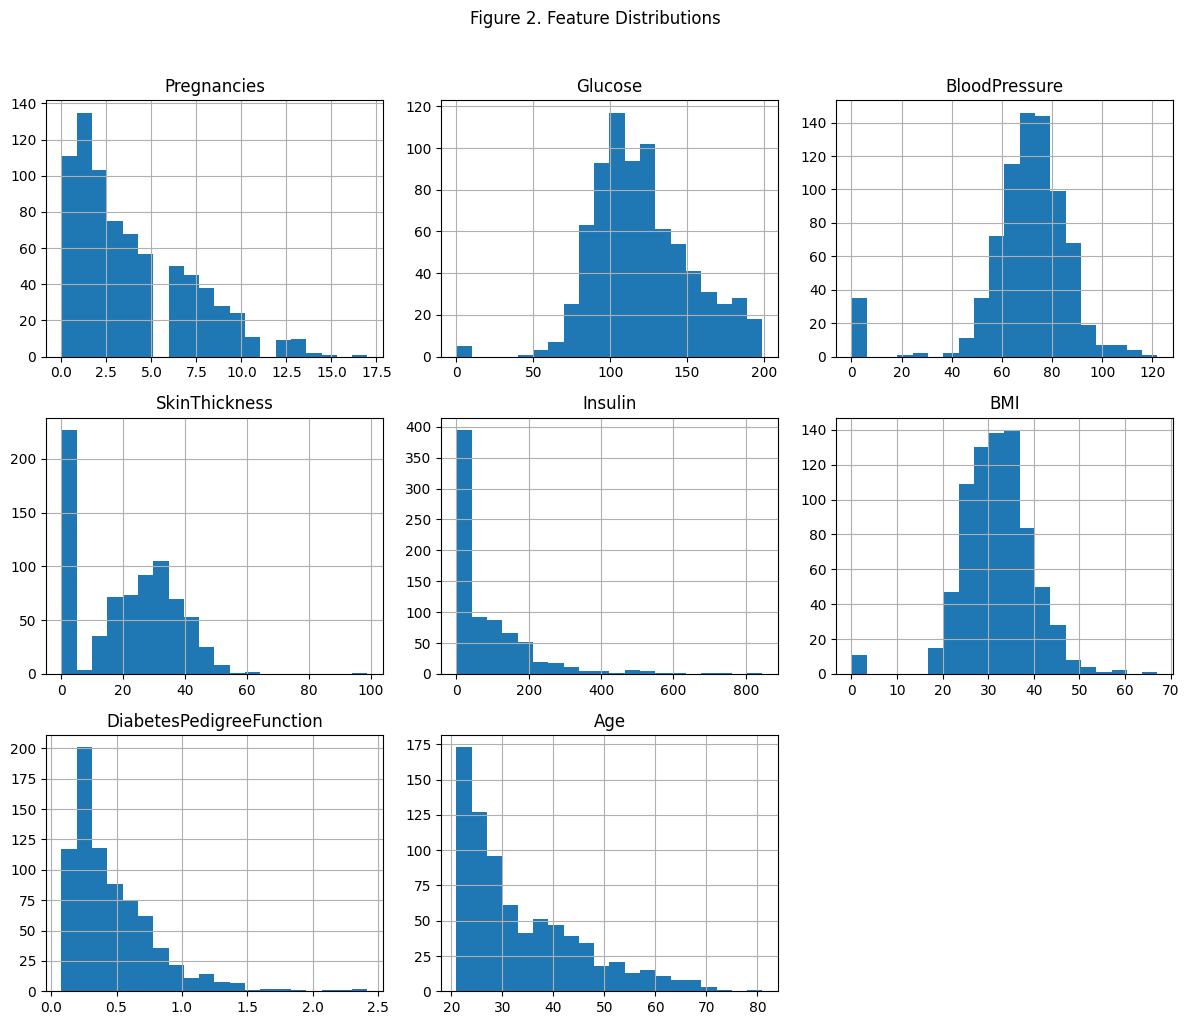

In [6]:
# Histograms of parameters (excluding target)
features = [c for c in df.columns if c != "Outcome"]

ax = df[features].hist(figsize=(12, 10), bins=20)
plt.suptitle("Figure 2. Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Mean and standard deviation of parameters
means = df[features].mean()
stds = df[features].std()

stats_df = pd.DataFrame({"mean": means, "std": stds})
display(stats_df)

,mean,std
Pregnancies,3.845052,3.369578
Glucose,120.894531,31.972618
BloodPressure,69.105469,19.355807
SkinThickness,20.536458,15.952218
Insulin,79.799479,115.244002
BMI,31.992578,7.884160
DiabetesPedigreeFunction,0.471876,0.331329
Age,33.240885,11.760232


,count
Outcome,
0,500
1,268


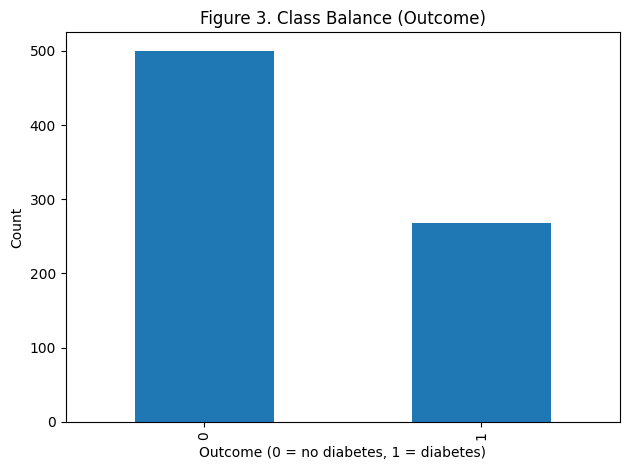

In [8]:
# Class balance
counts = df["Outcome"].value_counts().sort_index()
display(counts)

plt.figure()
counts.plot(kind="bar")
plt.title("Figure 3. Class Balance (Outcome)")
plt.xlabel("Outcome (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Train / Validation / Test split (60/20/20)

A stratified split is used so class proportions remain similar across splits.

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# From remaining 80%, take 25% for validation => 0.25 * 0.80 = 0.20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train class counts:\n", y_train.value_counts().sort_index())
print("Val class counts:\n", y_val.value_counts().sort_index())
print("Test class counts:\n", y_test.value_counts().sort_index())

Train: (460, 8) Val: (154, 8) Test: (154, 8)
Train class counts:
 Outcome
0    300
1    160
Name: count, dtype: int64
Val class counts:
 Outcome
0    100
1     54
Name: count, dtype: int64
Test class counts:
 Outcome
0    100
1     54
Name: count, dtype: int64


## Preprocessing (imputation + standardisation)

Many versions of this dataset encode missing measurements as **0** for some medical variables.
Common candidates:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

We treat 0 as missing *for these columns only*, then impute with the median.
Standardisation (mean=0, std=1) is applied to support LR and SVM.

All preprocessing is implemented inside a scikit-learn `Pipeline` so it is fit on the training data only.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

def replace_zeros_with_nan(X_df: pd.DataFrame) -> pd.DataFrame:
    X_df = X_df.copy()
    for col in zero_as_missing:
        if col in X_df.columns:
            X_df[col] = X_df[col].replace(0, np.nan)
    return X_df

zero_to_nan = FunctionTransformer(replace_zeros_with_nan, feature_names_out="one-to-one")

numeric_features = X.columns.tolist()

numeric_preprocess = Pipeline(steps=[
    ("zero_to_nan", zero_to_nan),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess = ColumnTransformer(
    transformers=[("num", numeric_preprocess, numeric_features)],
    remainder="drop"
)

## Model training, validation selection, and evaluation

We:
1. Train candidate hyperparameters on the training set
2. Select the best by **validation F1 score**
3. Refit the best setting on (train + validation)
4. Evaluate once on the held-out test set

In [11]:
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

@dataclass
class ModelResult:
    model_name: str
    best_params: Dict[str, Any]
    train_accuracy: float
    val_accuracy: float
    test_accuracy: float
    test_precision: float
    test_recall: float
    test_f1: float

def score_on_split(model, X_tr, y_tr, X_va, y_va) -> Tuple[float, float]:
    model.fit(X_tr, y_tr)
    y_tr_pred = model.predict(X_tr)
    y_va_pred = model.predict(X_va)
    return accuracy_score(y_va, y_va_pred), f1_score(y_va, y_va_pred)

def select_by_validation(model_name: str, base_pipeline: Pipeline, param_grid: List[Dict[str, Any]]):
    best = None
    for params in param_grid:
        pipe = base_pipeline.set_params(**params)
        val_acc, val_f1 = score_on_split(pipe, X_train, y_train, X_val, y_val)
        if (best is None) or (val_f1 > best["val_f1"]) or (val_f1 == best["val_f1"] and val_acc > best["val_acc"]):
            best = {"params": params, "val_acc": val_acc, "val_f1": val_f1}
    return best

def fit_and_test(model_name: str, pipeline: Pipeline, best_params: Dict[str, Any]) -> ModelResult:
    # Refit best on train+val
    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval = pd.concat([y_train, y_val], axis=0)

    best_pipe = pipeline.set_params(**best_params)
    best_pipe.fit(X_trainval, y_trainval)

    # Metrics on train, val (for reporting), and test
    y_train_pred = best_pipe.predict(X_train)
    y_val_pred = best_pipe.predict(X_val)
    y_test_pred = best_pipe.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    test_acc  = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec  = recall_score(y_test, y_test_pred)
    test_f1   = f1_score(y_test, y_test_pred)

    print(f"===== {model_name} =====")
    print("Best params:", best_params)
    print(f"Train Accuracy:      {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}")
    print()
    print("Classification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, digits=4))

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Figure. {model_name} Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.show()

    return ModelResult(
        model_name=model_name,
        best_params=best_params,
        train_accuracy=train_acc,
        val_accuracy=val_acc,
        test_accuracy=test_acc,
        test_precision=test_prec,
        test_recall=test_rec,
        test_f1=test_f1
    )

### 1) Logistic Regression

We tune `C` (regularisation strength) and solver.

Best (by validation F1): {'params': {'model__C': 0.01, 'model__solver': 'liblinear'}, 'val_acc': 0.8181818181818182, 'val_f1': 0.7142857142857143}
===== Logistic Regression =====
Best params: {'model__C': 0.01, 'model__solver': 'liblinear'}
Train Accuracy:      0.7652
Validation Accuracy: 0.8052
Test Accuracy:       0.7143

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.7800    0.7800    0.7800       100
           1     0.5926    0.5926    0.5926        54

    accuracy                         0.7143       154
   macro avg     0.6863    0.6863    0.6863       154
weighted avg     0.7143    0.7143    0.7143       154



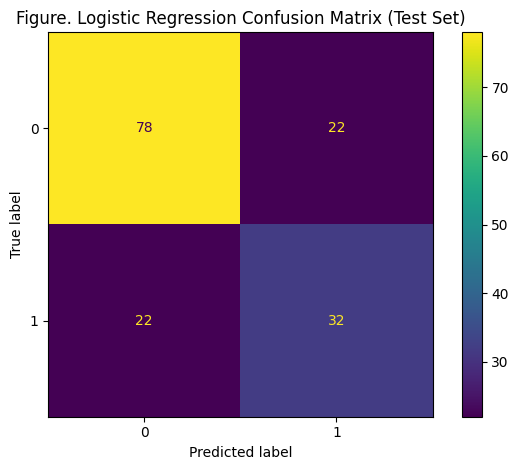

In [12]:
from sklearn.linear_model import LogisticRegression

log_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

log_grid = [
    {"model__C": c, "model__solver": "liblinear"} for c in [0.01, 0.1, 1, 10, 100]
] + [
    {"model__C": c, "model__solver": "lbfgs"} for c in [0.01, 0.1, 1, 10, 100]
]

best_log = select_by_validation("Logistic Regression", log_pipe, log_grid)
print("Best (by validation F1):", best_log)

log_result = fit_and_test("Logistic Regression", log_pipe, best_log["params"])

### 2) Support Vector Machine (RBF)

We tune `C` and `gamma`.

Best (by validation F1): {'params': {'model__C': 1, 'model__gamma': 0.01}, 'val_acc': 0.8051948051948052, 'val_f1': 0.6739130434782609}
===== Support Vector Machine =====
Best params: {'model__C': 1, 'model__gamma': 0.01}
Train Accuracy:      0.7761
Validation Accuracy: 0.8117
Test Accuracy:       0.7078

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.7434    0.8400    0.7887       100
           1     0.6098    0.4630    0.5263        54

    accuracy                         0.7078       154
   macro avg     0.6766    0.6515    0.6575       154
weighted avg     0.6965    0.7078    0.6967       154



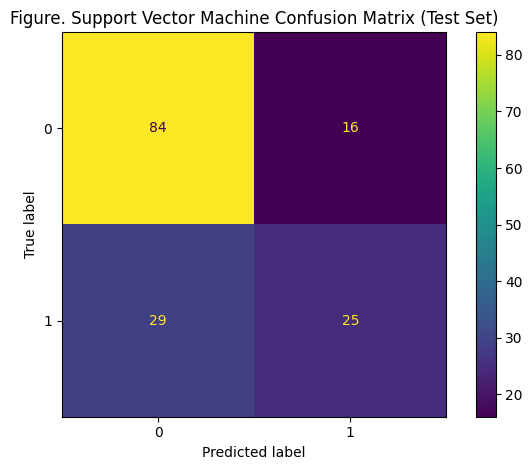

In [13]:
from sklearn.svm import SVC

svm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf"))
])

svm_grid = []
for c in [0.1, 1, 10, 100]:
    for g in ["scale", 0.01, 0.1, 1]:
        svm_grid.append({"model__C": c, "model__gamma": g})

best_svm = select_by_validation("Support Vector Machine", svm_pipe, svm_grid)
print("Best (by validation F1):", best_svm)

svm_result = fit_and_test("Support Vector Machine", svm_pipe, best_svm["params"])

### 3) Decision Tree

Trees do not require standardisation, but we keep preprocessing consistent.
We tune depth and minimum samples per leaf.

Best (by validation F1): {'params': {'model__max_depth': 4, 'model__min_samples_leaf': 5}, 'val_acc': 0.7857142857142857, 'val_f1': 0.6915887850467289}
===== Decision Tree =====
Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 5}
Train Accuracy:      0.7739
Validation Accuracy: 0.8247
Test Accuracy:       0.7987

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.8485    0.8400    0.8442       100
           1     0.7091    0.7222    0.7156        54

    accuracy                         0.7987       154
   macro avg     0.7788    0.7811    0.7799       154
weighted avg     0.7996    0.7987    0.7991       154



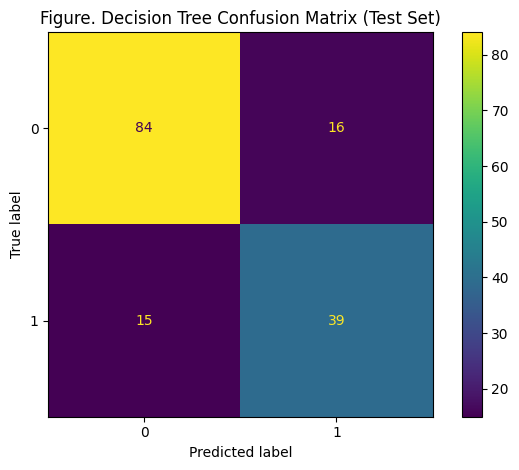

In [14]:
from sklearn.tree import DecisionTreeClassifier

tree_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_grid = []
for depth in [2, 3, 4, 5, 6, None]:
    for min_leaf in [1, 2, 5, 10]:
        tree_grid.append({"model__max_depth": depth, "model__min_samples_leaf": min_leaf})

best_tree = select_by_validation("Decision Tree", tree_pipe, tree_grid)
print("Best (by validation F1):", best_tree)

tree_result = fit_and_test("Decision Tree", tree_pipe, best_tree["params"])

## Comparison table (test set)

The table below supports a side-by-side comparison across models.

In [15]:
results_df = pd.DataFrame([
    {
        "Model": r.model_name,
        "Best Params": r.best_params,
        "Train Acc": r.train_accuracy,
        "Val Acc": r.val_accuracy,
        "Test Acc": r.test_accuracy,
        "Precision": r.test_precision,
        "Recall": r.test_recall,
        "F1": r.test_f1
    }
    for r in [log_result, svm_result, tree_result]
])

results_df

,Model,Best Params,Train Acc,Val Acc,Test Acc,Precision,Recall,F1
0,Logistic Regression,"{'model__C': 0.01, 'model__solver': 'liblinear'}",0.765217,0.805195,0.714286,0.592593,0.592593,0.592593
1,Support Vector Machine,"{'model__C': 1, 'model__gamma': 0.01}",0.776087,0.811688,0.707792,0.609756,0.462963,0.526316
2,Decision Tree,"{'model__max_depth': 4, 'model__min_samples_le...",0.773913,0.824675,0.798701,0.709091,0.722222,0.715596


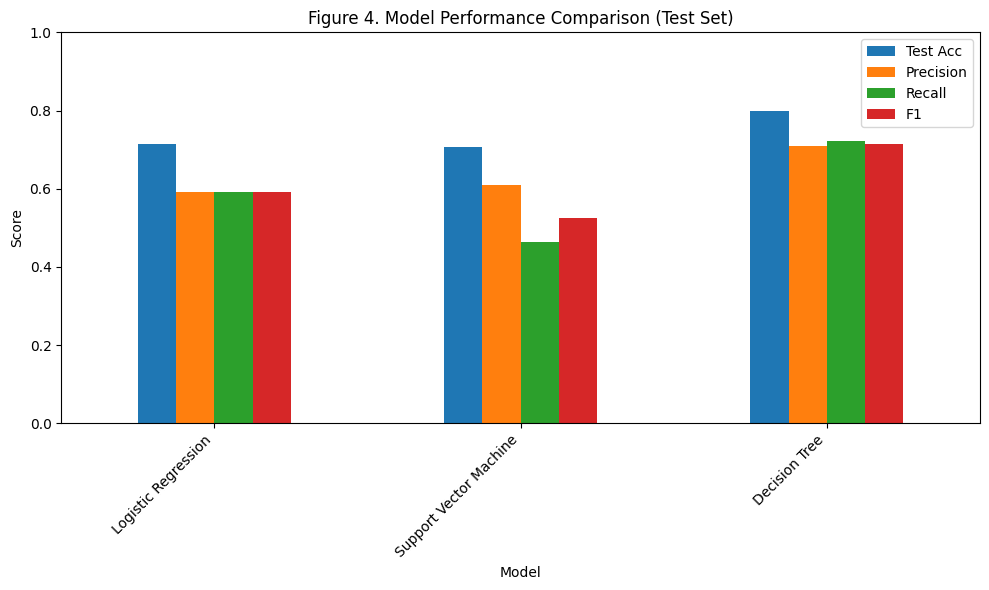

In [16]:
# Visual comparison of test metrics
plot_df = results_df.set_index("Model")[["Test Acc", "Precision", "Recall", "F1"]]
plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Figure 4. Model Performance Comparison (Test Set)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Notes for the report (copy/paste friendly)

- Describe the dataset, target variable (Outcome), and the train/val/test split.
- Report whether the dataset is balanced using the class counts/plot.
- Report data quality findings:
  - Any NaNs (explicit missing values)
  - Zeros in medical features treated as missing-like values
- Explain preprocessing:
  - Replacing invalid zeros with NaN for specific columns
  - Median imputation
  - Standardisation (mean=0, std=1)
  - Implemented via scikit-learn Pipelines to avoid data leakage
- In Results:
  - Include confusion matrices and the comparison table/plot
  - Interpret precision vs recall (medical context often values recall)
  - Comment on overfitting by comparing train vs test performance